## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = Anderson Varela,Gabriel Camargo, Julian Sanchez y Juan Pablo Guerrero 
carnet = 1000116567,1000114473, 1000113984, 1000115135


## 1) Descripción del problema **[1 pts]**

Una pequeña tienda quiere desarrollar un programa con el cual pueda atender usuarios guardar cada venta o cosa que se haga y poder tener control sobre sus productos y para ello se piensa en usar colas para atender a los clientes, pilas para guardar las operaciones y clientes cada vez por ultimo listas doblemente enlazadas para mantener un control de los productos en cada venta


## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

Requerimientos Funcionales

Agregar nuevos clientes a la cola (FIFO)

Atender al siguiente cliente en cola

Apilar clientes atendidos (LIFO)

Deshacer última atención y recolocar cliente

Gestionar catálogo: agregar, listar, buscar y eliminar productos

Recorrer productos en ambos sentidos

Requerimientos No Funcionales

Operaciones de cola y pila 

Búsqueda en ambas direcciones

Interfaz de texto clara y responsiva

Manejo seguro de casos límite (lista vacía)

Código modular, legible y mantenible


## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:

1.Cliente en espera
Como cajero, quiero añadir clientes a la cola, para que sean atendidos en el orden de llegada.

2.Atender siguiente
Como trabajador, quiero atender al siguiente cliente de la cola, para registrarlo automáticamente en el historial de atenciones.

3.Deshacer atención
Como cajero, quiero deshacer la última atención realizada, para devolver al cliente al inicio de la cola.

4.Gestionar inventario
Como encargado, quiero agregar, buscar y eliminar productos del catálogo mediante su código, para mantener actualizado el inventario.


## 4) Diagramas de flujo **[5 pts]**

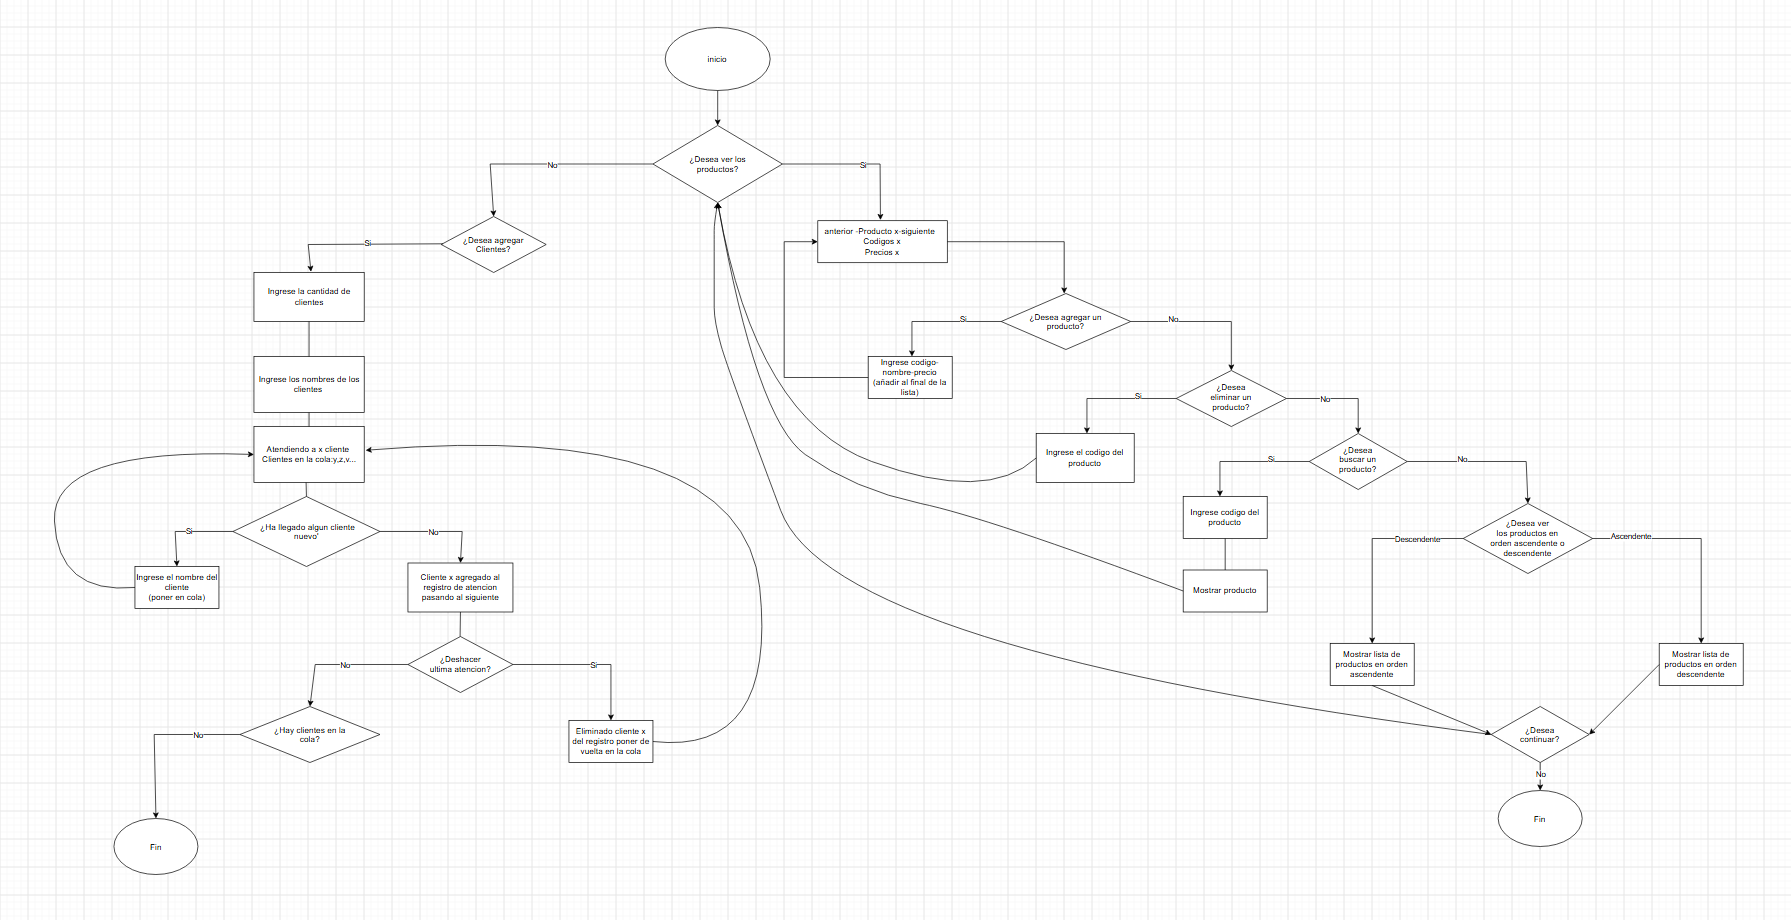


El programa inicia preguntandole al usuario si desea ver los productos en dado caso de que si muestra la lista de productos  y pregunta: ¿quiere añadir productos?,desea eliminar un producto,buscar un producto o ver la losta en orden ascendente o descendente,en el caso no querer ver los productos se preguntara sobre los clientes y si se desea añadir añadir y se atenderá a los mismos en forma dde cola y depsues de atender a uno se seguira con el otro dando la opcion de deshacer la ultima atencion registrada y añadir nuevos clientes en dado caso de no necesitar nada en ningun caso el programa terminará o al acabarse los clientes


## 5) Diagramas de secuencia **[5 pts]**

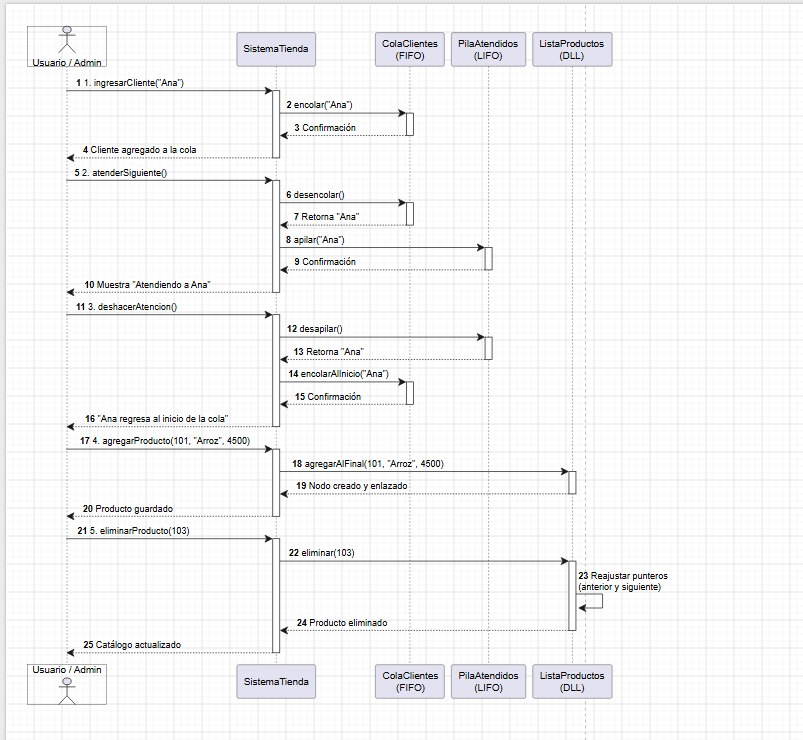

Gestión de Clientes (Cola FIFO - First In, First Out)
Ingreso de cliente: El usuario/administrador invoca ingresarCliente("Ana"). El sistema llama al método encolar("Ana") sobre la ColaClientes. Al ser una cola (FIFO), el primer cliente en llegar es el primero que estará listo para ser atendido.

Atención de cliente: Cuando se llama a atenderSiguiente(), el sistema ejecuta desencolar() para retirar a "Ana" de la cola. Inmediatamente, la registra en la PilaAtendidos mediante apilar("Ana") para mantener un historial de atención.


Deshacer Operación (Pila LIFO - Last In, First Out)
Reversión de atención: Si se ejecuta deshacerAtencion(), el sistema consulta la PilaAtendidos y realiza un desapilar(). Dado que la pila opera bajo LIFO, recupera al último cliente atendido ("Ana").


Restauración: Para deshacer la acción correctamente sin alterar el orden original, el sistema reinserta al cliente al frente de la cola mediante encolarAlInicio("Ana").


 Catálogo de Productos (Lista Doblemente Enlazada - DLL)
Agregar producto: Al invocar agregarProducto(101, "Arroz", 4500), el sistema invoca agregarAlFinal(...) en la ListaProductos. La estructura crea un nuevo nodo y actualiza sus punteros correspondientes.
Eliminar producto: Para eliminarProducto(103), la lista busca el nodo correspondiente y ejecuta el reajuste de punteros (anterior y siguiente), permitiendo la remoción eficiente del elemento sin reestructurar toda la colección.

## 6) Diagramas de casos de uso **[5 pts]**
Incluye el diagrama que muestre el proceso general

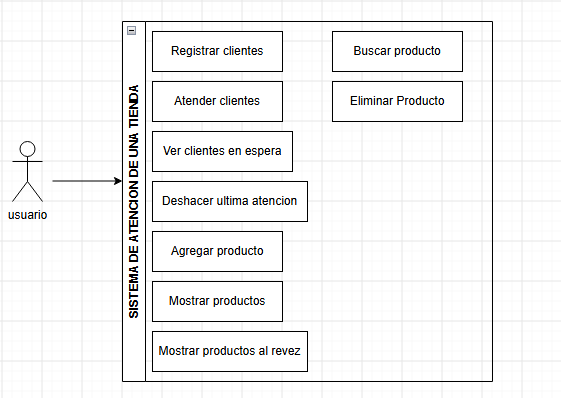

El usuario al interactuar con el sistema puede registrar clientes, atenderlos, ver los clientes en espera y deshacer la ultima atencion.Tambien puede agregar, mostrar y buscar productos ademas de recorrer la lista de productos en ambos sentidos y poder eliminar cualquier producto.


## 7) Análisis de complejidad **[5 pts]**

- Justificación

El código utiliza colas, pilas y una lista doblemente enlazada.

Las operaciones que acceden directamente a un nodo (frente, final o tope) tienen complejidad O(1).

Las operaciones que utilizan while para recorrer los elementos tienen complejidad O(n).

En buscar() y eliminar() se debe recorrer la lista hasta encontrar el producto, por lo que pueden llegar a ser O(n).

- Función T[n]

T[n] para las tres funciones T[n] = c1 + c2n = O(n)

- Mejor y peor caso con gráfica

Mejor caso

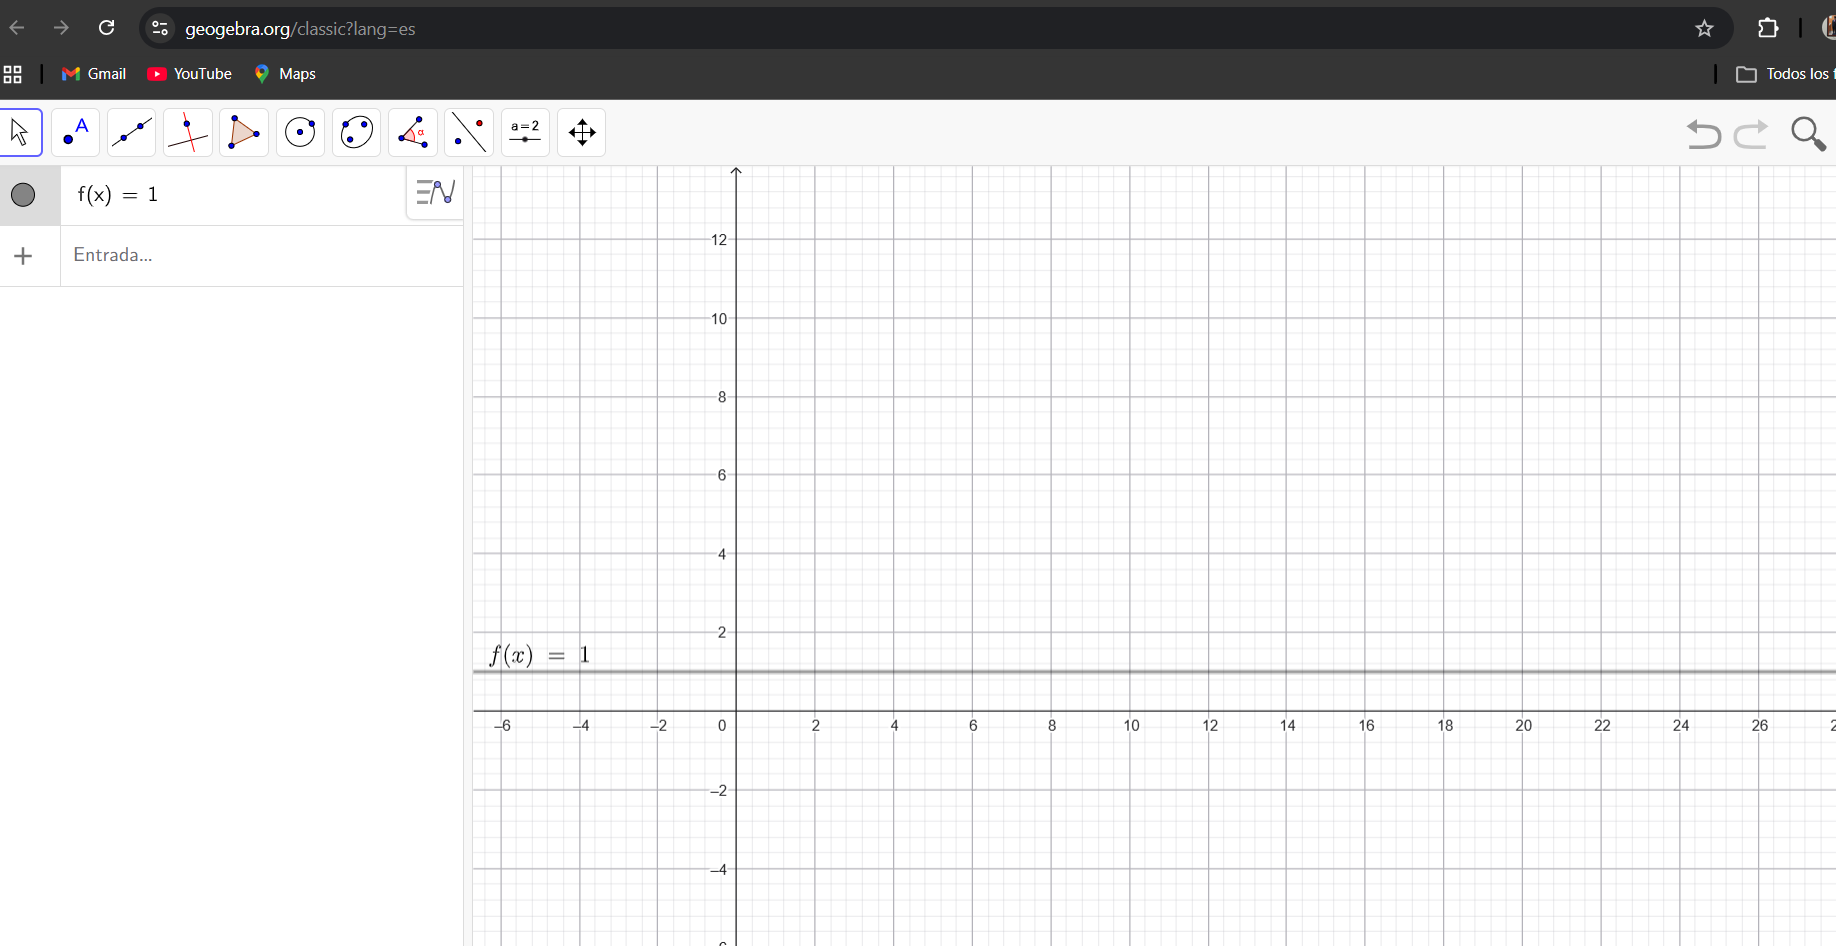

Peor caso

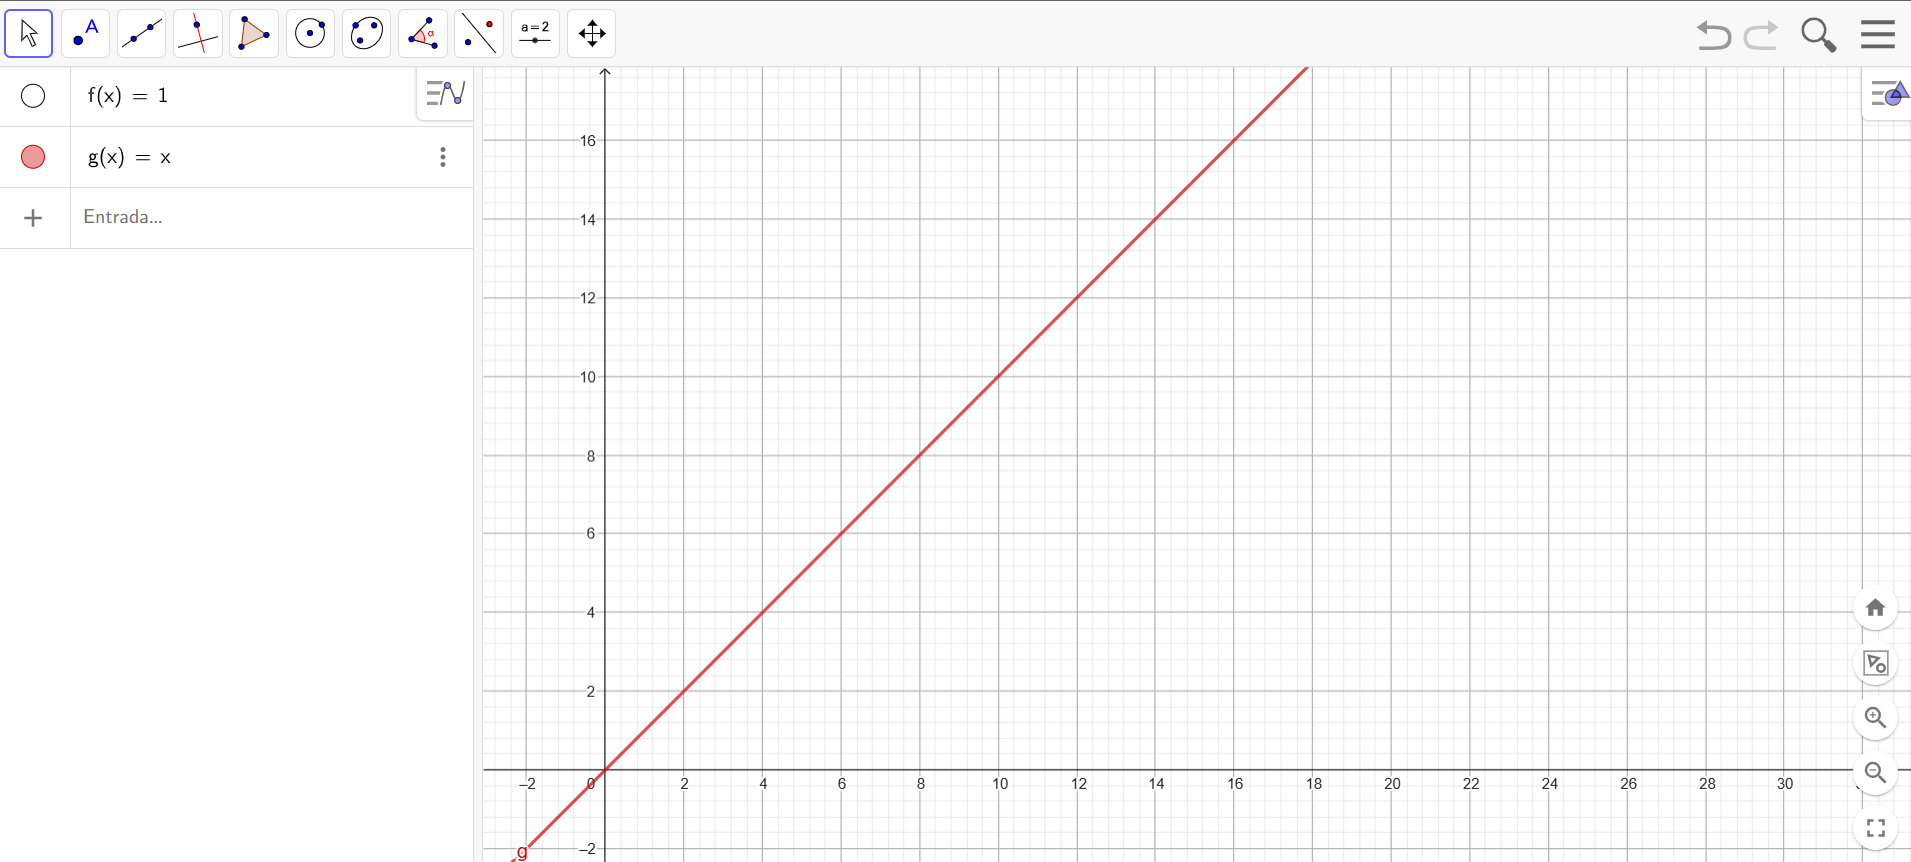




## 8) Código funcional **[10 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
# ==========================================
# SISTEMA DE ATENCIÓN
# ==========================================

class SistemaTienda:
    def __init__(self):
        self.cola = ColaClientes()
        self.pila = PilaAtendidos()

    # Registrar cliente
    def agregar_cliente(self, nombre):
        self.cola.agregar(nombre)

    # Atender cliente
    def atender_cliente(self):
        cliente = self.cola.atender()

        if cliente is not None:
            self.pila.apilar(cliente)

        return cliente

    # Ver último cliente atendido
    def ultimo_atendido(self):
        return self.pila.ver_tope()

    # Deshacer última atención
    def deshacer_atencion(self):
        cliente = self.pila.desapilar()

        if cliente is not None:
            self.cola.agregar_inicio(cliente)

        return cliente
# ==========================================
# NODO PARA CLIENTES
# ==========================================

class NodoCliente:
    def __init__(self, nombre):
        self.nombre = nombre
        self.siguiente = None


# ==========================================
# COLA DE CLIENTES
# ==========================================

class ColaClientes:
    def __init__(self):
        self.frente = None
        self.final = None

    # Agregar cliente al final
    def agregar(self, nombre):
        nuevo = NodoCliente(nombre)

        if self.frente is None:
            self.frente = nuevo
            self.final = nuevo
        else:
            self.final.siguiente = nuevo
            self.final = nuevo

    # Agregar cliente al inicio
    
    def agregar_inicio(self, nombre):
        nuevo = NodoCliente(nombre)

        if self.frente is None:
            self.frente = nuevo
            self.final = nuevo
        else:
            nuevo.siguiente = self.frente
            self.frente = nuevo

    # Atender al primer cliente
    def atender(self):
        if self.frente is None:
            return None

        cliente = self.frente
        self.frente = self.frente.siguiente

        if self.frente is None:
            self.final = None

        return cliente.nombre

    # Mostrar clientes
    def mostrar(self):
        actual = self.frente
        resultado = ""

        while actual is not None:
            if resultado != "":
                resultado += " -> "

            resultado += actual.nombre
            actual = actual.siguiente

        return resultado


# ==========================================
# NODO PARA LA PILA
# ==========================================

class NodoPila:
    def __init__(self, nombre):
        self.nombre = nombre
        self.siguiente = None


# ==========================================
# PILA DE CLIENTES ATENDIDOS
# ==========================================

class PilaAtendidos:
    def __init__(self):
        self.tope = None

    # Agregar cliente atendido
    def apilar(self, nombre):
        nuevo = NodoPila(nombre)

        nuevo.siguiente = self.tope
        self.tope = nuevo

    # Sacar último cliente atendido
    def desapilar(self):
        if self.tope is None:
            return None

        cliente = self.tope
        self.tope = self.tope.siguiente

        return cliente.nombre

    # Ver último cliente atendido
    def ver_tope(self):
        if self.tope is None:
            return None

        return self.tope.nombre

    # Mostrar pila
    def mostrar(self):
        actual = self.tope
        resultado = ""

        while actual is not None:
            if resultado != "":
                resultado += " -> "

            resultado += actual.nombre
            actual = actual.siguiente

        return resultado


# ==========================================
# NODO PARA PRODUCTOS
# ==========================================

class NodoProducto:
    def __init__(self, codigo, nombre, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.precio = precio

        self.anterior = None
        self.siguiente = None




class Catalogo:
    def __init__(self):
        self.inicio = None
        self.final = None

    # Agregar producto al final
    def agregar(self, codigo, nombre, precio):
        nuevo = NodoProducto(codigo, nombre, precio)

        if self.inicio is None:
            self.inicio = nuevo
            self.final = nuevo
        else:
            nuevo.anterior = self.final
            self.final.siguiente = nuevo
            self.final = nuevo

    # Mostrar desde el primero hasta el último
    def mostrar_adelante(self):
        actual = self.inicio
        resultado = ""

        while actual is not None:
            if resultado != "":
                resultado += " -> "

            resultado += str(actual.codigo) + " - " + actual.nombre
            actual = actual.siguiente

        return resultado

    # Mostrar desde el último hasta el primero
    def mostrar_atras(self):
        actual = self.final
        resultado = ""

        while actual is not None:
            if resultado != "":
                resultado += " -> "

            resultado += str(actual.codigo) + " - " + actual.nombre
            actual = actual.anterior

        return resultado

    # Buscar por código
    def buscar(self, codigo):
        actual = self.inicio

        while actual is not None:

            if actual.codigo == codigo:
                return actual

            actual = actual.siguiente

        return None

    # Eliminar por código
    def eliminar(self, codigo):
        actual = self.inicio

        while actual is not None:

            if actual.codigo == codigo:

                # Si es el primer nodo
                if actual.anterior is None:
                    self.inicio = actual.siguiente
                else:
                    actual.anterior.siguiente = actual.siguiente

                # Si es el último nodo
                if actual.siguiente is None:
                    self.final = actual.anterior
                else:
                    actual.siguiente.anterior = actual.anterior

                return True

            actual = actual.siguiente

        return False


## 9) pruebas **[15 pts]**

In [ ]:
def prueba_1():
    tienda = SistemaTienda()

    tienda.agregar_cliente("Ana")
    tienda.agregar_cliente("Carlos")
    tienda.agregar_cliente("Laura")

    tienda.atender_cliente()

    return tienda.cola.mostrar()


input = "Atender primer cliente"
output = "Carlos - Laura"

test(prueba_1(), output)


def prueba_2():
    tienda = SistemaTienda()

    tienda.agregar_cliente("Ana")
    tienda.agregar_cliente("Carlos")
    tienda.agregar_cliente("Laura")

    tienda.atender_cliente()
    tienda.atender_cliente()
    tienda.atender_cliente()

    return tienda.ultimo_atendido()


input = "Consultar último cliente atendido"
output = "Laura"

test(prueba_2(), output)


def prueba_3():
    tienda = SistemaTienda()

    tienda.agregar_cliente("Ana")
    tienda.agregar_cliente("Carlos")
    tienda.agregar_cliente("Laura")

    tienda.atender_cliente()
    tienda.atender_cliente()

    tienda.deshacer_atencion()

    return tienda.cola.mostrar()


input = "Deshacer última atención"
output = "Carlos - Laura"

test(prueba_3(), output)


def prueba_4():
    catalogo = Catalogo()

    catalogo.agregar(101, "Arroz", 4500)
    catalogo.agregar(102, "Leche", 3800)
    catalogo.agregar(103, "Pan", 2500)

    return catalogo.mostrar_adelante()


input = "Mostrar catálogo hacia adelante"
output = "101 - Arroz - 102 - Leche - 103 - Pan"

test(prueba_4(), output)

def prueba_5():
    catalogo = Catalogo()

    catalogo.agregar(101, "Arroz", 4500)
    catalogo.agregar(102, "Leche", 3800)
    catalogo.agregar(103, "Pan", 2500)

    return catalogo.mostrar_atras()


input = "Mostrar catálogo hacia atrás"
output = "103 - Pan - 102 - Leche - 101 - Arroz"

test(prueba_5(), output)

def prueba_6():
    catalogo = Catalogo()

    catalogo.agregar(101, "Arroz", 4500)
    catalogo.agregar(102, "Leche", 3800)
    catalogo.agregar(103, "Pan", 2500)

    producto = catalogo.buscar(102)

    if producto is not None:
        return producto.nombre

    return "No encontrado"


input = "Buscar producto 102"
output = "Leche"

test(prueba_6(), output)

def prueba_7():
    catalogo = Catalogo()

    catalogo.agregar(101, "Arroz", 4500)
    catalogo.agregar(102, "Leche", 3800)
    catalogo.agregar(103, "Pan", 2500)

    catalogo.eliminar(102)

    return catalogo.mostrar_adelante()


input = "Eliminar producto 102"
output = "101 - Arroz - 103 - Pan"

test(prueba_7(), output)

## Pruebas de enunciado

¿Qué va aquí?

Casos de prueba proporcionados por el enunciado.

Entrada usada.

Salida esperada.

Salida obtenida.

In [1]:
#Prueba 1 Atender primer cliente
input = "Ana"
Salida_esperada = "Ana, Carlos, Laura, Mateo -> atender", "Carlos -> Laura -> Mateo"
output = "Carlos, Laura, Mateo"

test(input,output)

#Prueba 2 Agregar nuevo cliente
input = "Sofía"
Salida_esperada =  "Carlos -> Laura -> Mateo + Sofía", "Carlos -> Laura -> Mateo -> Sofía"
output =  "Carlos, Laura, Mateo, Sofía"

test(input,output)

#Prueba 3 Mostrar los clientes en espera
input = "Cola"
Salida_esperada =  "Carlos, Laura, Mateo, Sofía"
output =  "Carlos, Laura, Mateo, Sofía"




NameError: name 'test' is not defined

## Pruebas propias
¿Qué va aquí?

Casos creados por usted.

Casos tomados de [UDebug](https://www.udebug.com/) (si aplica).


In [ ]:
input, output = "123", "123"
test(input,output)

Paso caso de prueba 123 -> 123


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking

Generando datos ............

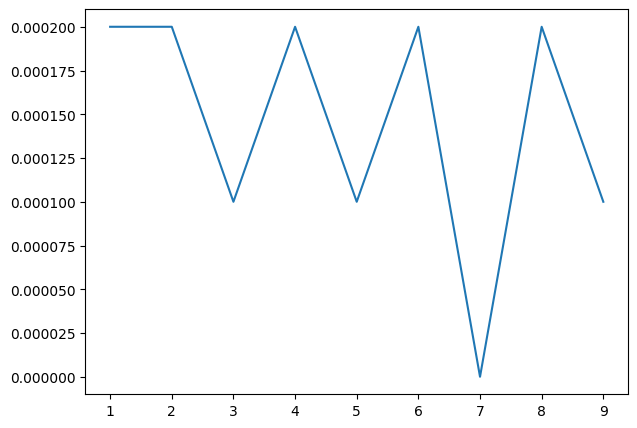

In [ ]:
# Calcula el tiempo de ejecucion con base a diferentes tamaños de la entrada
# y nos da una lista de resultados, cada resultado contiene el tamaño de la entrada
# y el tiempo de ejecucion
# TENER EN CUENTA ESTAS ENTRADAS PUEDEN VARIAR SEGÚN EL PROBLEMA


def bench(n: int, step: int = 1) -> list[tuple[int, float]]:
    print("Generando datos ...", end='')
    from random import randint
    import time
    results: list[tuple[int, float]] = []


    # AJUSTAR LAS ENTRADAS SEGÚN EL PROBLEMA
    for size in range(1, n, step):
        input = size

        ti = time.perf_counter()
        output = input # Ajustar a su función
        tf = time.perf_counter()


        delta = (tf - ti) * 1000
        print(".", end="")
        results.append((size, delta))
    return results


# === CODIGO PARA DIBUJAR ===


def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)
    import matplotlib.pyplot as plt
    plt.figure(figsize=dimensiones)
    plt.plot(x, y)
    plt.show()


# === LLAMADO ===
tiempos = bench(10, step=1)


x = [size for size, timing in tiempos]
y = [timing for size, timing in tiempos]


dibujar(x, y)